In [1]:
import os
import cv2
import random
from pathlib import Path
from tqdm import tqdm

In [2]:
real_path = Path(r"C:\Users\aadit\Downloads\Celeb-real")
fake_path = Path(r"C:\Users\aadit\Downloads\Celeb-synthesis")

In [3]:
real_videos = sorted(list(real_path.glob("*.mp4")))
fake_videos = sorted(list(fake_path.glob("*.mp4")))

print(len(real_videos))
print(len(fake_videos))

590
5639


In [4]:
random.seed(42)

fake_videos = random.sample(fake_videos, len(real_videos))

print(len(fake_videos))

590


In [18]:
from sklearn.model_selection import train_test_split
real_train, real_temp = train_test_split(real_videos, test_size = 0.2, random_state = 42)
real_val, real_test = train_test_split(real_temp, test_size = 0.5, random_state = 42)
fake_train, fake_temp = train_test_split(fake_videos, test_size = 0.2, random_state = 42)
fake_val, fake_test = train_test_split(fake_temp, test_size = 0.5, random_state = 42)
print(len(real_train), len(real_val), len(real_test))
print(len(fake_train), len(fake_val), len(fake_test))

472 59 59
472 59 59


In [7]:
splits = {
    "train": (real_train, fake_train),
    "val": (real_val, fake_val),
    "test": (real_test, fake_test)
}

for split in splits:
    for label in ["real", "fake"]:
        os.makedirs(f"processed/{split}/{label}", exist_ok=True)

In [8]:
from PIL import Image
from facenet_pytorch import MTCNN
import cv2, os, torch

device='cuda' if torch.cuda.is_available() else 'cpu'
mtcnn=MTCNN(keep_all=False, device=device)

def process_video(video_path, output_dir, interval=15, max_faces=5):
    cap=cv2.VideoCapture(str(video_path))
    frame_idx=0
    saved=0
    while saved<max_faces:
        ret, frame=cap.read()
        if not ret:
            break
        if frame_idx % interval==0:
            rgb=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil=Image.fromarray(rgb)
            boxes, probs = mtcnn.detect(pil)
            if boxes is not None and len(boxes)>0:
                x1,y1,x2,y2=boxes[0]
                x1=max(0,int(x1)); y1=max(0,int(y1))
                x2=min(frame.shape[1],int(x2)); y2=min(frame.shape[0],int(y2))
                face=frame[y1:y2, x1:x2]
                if face.size!=0:
                    face=cv2.resize(face,(224,224))
                    save_path=os.path.join(output_dir,f"{video_path.stem}_{saved}.jpg")
                    cv2.imwrite(save_path, face)
                    saved+=1
        frame_idx+=1
    cap.release()


C:\Users\aadit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(
    image_size=224,
    margin=20,
    keep_all=False,
    device=device
)

In [10]:
for split, (real_list, fake_list) in splits.items():

    print(f"\nProcessing {split}")

    for video in tqdm(real_list):

        process_video(
            video,
            f"processed/{split}/real"
        )

    for video in tqdm(fake_list):

        process_video(
            video,
            f"processed/{split}/fake"
        )

print("Finished")
        
        


Processing train


100%|██████████| 472/472 [09:38<00:00,  1.22s/it]  



Processing val


100%|██████████| 59/59 [00:40<00:00,  1.46it/s]



Processing test


100%|██████████| 59/59 [00:40<00:00,  1.46it/s]

Finished


processed/train/real\id34_0009_1.jpg


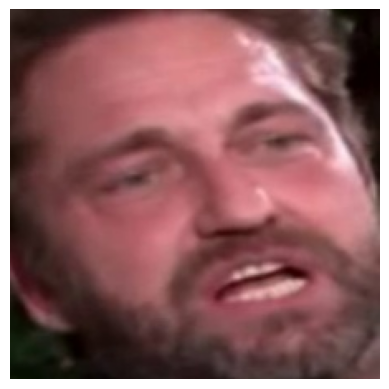

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import glob

imgs = glob.glob("processed/train/real/*.jpg")

sample = random.choice(imgs)

img = Image.open(sample)

plt.imshow(img)

plt.axis("off")

print(sample)